In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load activation data
print("Loading activation data...")
orig_activations = np.load('/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/all_original_activations.npy')
opt_activations = np.load('/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/all_optimized_activations.npy')

print(f"Original activations shape: {orig_activations.shape}")
print(f"Optimized activations shape: {opt_activations.shape}")
print(f"  - {orig_activations.shape[0]} sequences")
print(f"  - {orig_activations.shape[1]} filters\n")

# Load metadata
print("Loading metadata...")
metadata = pd.read_csv('/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/all_sequences_metadata.tsv', sep='\t')
print(f"Metadata shape: {metadata.shape}")
print(f"Columns: {list(metadata.columns)}\n")

# Load filter comparison results
print("Loading filter comparison results...")
filter_results = pd.read_csv('/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/suppressing_CTCFs/results_repeated/filter_comparison_results.tsv', sep='\t')
print(f"Filter results shape: {filter_results.shape}")
print(f"\nFirst few rows:")
filter_results.head()

Loading activation data...
Original activations shape: (348, 128)
Optimized activations shape: (348, 128)
  - 348 sequences
  - 128 filters

Loading metadata...
Metadata shape: (348, 31)
Columns: ['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end', 'centered_flat_start', 'centered_flat_end', 'active_fraction', 'neutral_fraction', 'repressive_fraction', 'ctcf_motif_locs', 'last_accepted_step', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init', 'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num', 'CTCFs_num', 'avg_orig_fimo_scores', 'avg_new_fimo_scores', 'orig_CTCFs_coord', 'new_CTCFs_coord', 'avg_orig_left_fimo_scores', 'avg_new_left_fimo_scores', 'avg_orig_right_fimo_scores', 'avg_new_right_fimo_scores', 'URQ_diff']

Loading filter comparison results...
Filter results shape: (128, 27)

First few rows:


,filter_idx,orig_mean,orig_std,orig_median,opt_mean,opt_std,opt_median,mean_diff,median_diff,abs_mean_diff,...,correlation,correlation_pvalue,pct_increased,orig_min,orig_max,opt_min,opt_max,significant_001,significant_01,significant_05
0,6,2.644862,0.148146,2.627191,2.685987,0.179992,2.654371,0.041125,0.027180,0.041125,...,0.740052,1.427073e-61,13.218391,2.337303,3.042608,2.344089,3.101829,True,True,True
1,26,2.985890,0.128318,2.968796,3.010183,0.124951,3.010197,0.024293,0.041401,0.024293,...,0.850657,1.211020e-98,16.091954,2.693316,3.418563,2.693316,3.418563,True,True,True
2,31,3.163193,0.159288,3.133069,3.173005,0.169292,3.138601,0.009812,0.005531,0.009812,...,0.931702,3.038787e-154,4.022989,2.874464,3.712299,2.874464,3.712299,False,True,True
3,115,2.877627,0.146342,2.861470,2.885432,0.149053,2.866915,0.007806,0.005445,0.007806,...,0.952041,4.986866e-180,6.609195,2.570127,3.341210,2.581187,3.341210,False,True,True
4,90,3.785444,0.210406,3.762923,3.793037,0.208634,3.764027,0.007592,0.001104,0.007592,...,0.970156,5.533149e-215,5.172414,3.207215,4.389836,3.207215,4.389836,False,True,True


In [7]:
filter_results[["filter_idx", "opt_mean", "opt_median"]].sort_values("opt_mean", ascending=False).head(20)

,filter_idx,opt_mean,opt_median
45,118,3.885545,3.886123
4,90,3.793037,3.764027
79,59,3.785975,3.789836
22,98,3.542651,3.534423
65,116,3.528808,3.506731
7,63,3.524802,3.525330
104,125,3.521012,3.506082
19,27,3.479611,3.451589
59,62,3.462677,3.449250
18,37,3.461590,3.455364


In [ ]:
# Summary statistics
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)

print(f"\nDataset:")
print(f"  Total sequences: {len(orig_activations)}")
print(f"  Total filters: {orig_activations.shape[1]}")
print(f"  Folds: {sorted(metadata['fold'].unique())}")

print(f"\nSignificant filters (p < 0.05): {filter_results['significant_05'].sum()} ({100*filter_results['significant_05'].mean():.1f}%)")
print(f"Highly significant (p < 0.001): {filter_results['significant_001'].sum()} ({100*filter_results['significant_001'].mean():.1f}%)")

print(f"\nEffect sizes:")
print(f"  Small (|d| > 0.2): {(np.abs(filter_results['cohens_d']) > 0.2).sum()}")
print(f"  Medium (|d| > 0.5): {(np.abs(filter_results['cohens_d']) > 0.5).sum()}")
print(f"  Large (|d| > 0.8): {(np.abs(filter_results['cohens_d']) > 0.8).sum()}")

print(f"\nTop 5 most differential filters:")
print(filter_results[['filter_idx', 'mean_diff', 'fold_change', 't_pvalue', 'cohens_d']].head())

In [ ]:
# Look at the top differential filter in detail
top_filter_idx = filter_results.iloc[0]['filter_idx']

print(f"Top differential filter: Filter {top_filter_idx}")
print("\nDetailed statistics:")
print(filter_results.iloc[0].to_string())

In [ ]:
# Visualize top filter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

orig_vals = orig_activations[:, top_filter_idx]
opt_vals = opt_activations[:, top_filter_idx]

# Histogram
bins = np.linspace(min(orig_vals.min(), opt_vals.min()),
                   max(orig_vals.max(), opt_vals.max()), 30)
axes[0].hist(orig_vals, bins=bins, alpha=0.6, label='Original', color='steelblue', density=True)
axes[0].hist(opt_vals, bins=bins, alpha=0.6, label='Optimized', color='coral', density=True)
axes[0].axvline(orig_vals.mean(), color='blue', linestyle='--', linewidth=2)
axes[0].axvline(opt_vals.mean(), color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Max Activation')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Filter {top_filter_idx} Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter plot
axes[1].scatter(orig_vals, opt_vals, alpha=0.5, s=30)
max_val = max(orig_vals.max(), opt_vals.max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x')
axes[1].set_xlabel('Original Activation')
axes[1].set_ylabel('Optimized Activation')
axes[1].set_title(f'Filter {top_filter_idx} Correlation')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Box plot
data_to_plot = [orig_vals, opt_vals]
bp = axes[2].boxplot(data_to_plot, labels=['Original', 'Optimized'],
                     patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
axes[2].set_ylabel('Max Activation')
axes[2].set_title(f'Filter {top_filter_idx} Comparison')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'filter_{top_filter_idx}_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Get top N filters
N = 10
top_filters = filter_results.head(N)['filter_idx'].values

print(f"Top {N} differential filters: {top_filters}")

# Create comparison plot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, filter_idx in enumerate(top_filters):
    orig = orig_activations[:, filter_idx]
    opt = opt_activations[:, filter_idx]
    
    axes[i].scatter(orig, opt, alpha=0.5, s=20)
    max_val = max(orig.max(), opt.max())
    axes[i].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
    
    # Get stats
    row = filter_results[filter_results['filter_idx'] == filter_idx].iloc[0]
    
    axes[i].set_title(f'Filter {filter_idx}\n'
                     f'FC: {row["fold_change"]:.2f}x, p={row["t_pvalue"]:.1e}',
                     fontsize=10)
    axes[i].set_xlabel('Original', fontsize=9)
    axes[i].set_ylabel('Optimized', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('top_10_filters_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate activation changes
activation_changes = opt_activations - orig_activations  # shape: (n_seqs, 128)

# Mean change per filter
mean_changes = activation_changes.mean(axis=0)  # shape: (128,)

print(f"Mean activation changes per filter:")
print(f"  Mean: {mean_changes.mean():.4f}")
print(f"  Std: {mean_changes.std():.4f}")
print(f"  Min: {mean_changes.min():.4f} (Filter {mean_changes.argmin()})")
print(f"  Max: {mean_changes.max():.4f} (Filter {mean_changes.argmax()})")

In [ ]:
# Cluster filters by activation patterns
# Use mean activation in original and optimized
mean_orig = orig_activations.mean(axis=0)  # (128,)
mean_opt = opt_activations.mean(axis=0)    # (128,)

# Stack for clustering
patterns = np.vstack([mean_orig, mean_opt])  # (2, 128)

# Hierarchical clustering
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Dendrogram
linkage = hierarchy.linkage(patterns.T, method='ward')
dendro = hierarchy.dendrogram(linkage, ax=axes[0], no_labels=True)
axes[0].set_title('Filter Clustering by Activation Pattern', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Filter Index', fontsize=12)
axes[0].set_ylabel('Distance', fontsize=12)

# Correlation heatmap of top filters
top_20_filters = filter_results.head(20)['filter_idx'].values
corr_matrix = np.corrcoef(opt_activations[:, top_20_filters].T)

im = axes[1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_xticks(np.arange(len(top_20_filters)))
axes[1].set_yticks(np.arange(len(top_20_filters)))
axes[1].set_xticklabels([f"F{i}" for i in top_20_filters], rotation=45, fontsize=8)
axes[1].set_yticklabels([f"F{i}" for i in top_20_filters], fontsize=8)
axes[1].set_title('Top 20 Filters Correlation\n(Optimized Sequences)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Correlation')

plt.tight_layout()
# plt.savefig('filter_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import torch
import sys
import os

In [12]:
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
from akita_model.model import SeqNN

In [9]:
def extract_filter_weights(model, filter_indices=None):
    """
    Extract weight matrices from first convolutional layer.
    
    Args:
        model: Loaded SeqNN model
        filter_indices: List of filter indices to extract (or None for all)
    
    Returns:
        weights: numpy array of shape (kernel_size, 4, n_filters)
                 or (kernel_size, 4, len(filter_indices)) if specific filters requested
    """
    # Get first conv layer
    first_conv = model.conv_block_1.conv
    
    # Get weights: shape is (out_channels, in_channels, kernel_size)
    # For our case: (128, 4, 15)
    conv_weights = first_conv.weight.data.cpu().numpy()
    
    print(f"Conv weights shape: {conv_weights.shape}")
    print(f"  Output channels (filters): {conv_weights.shape[0]}")
    print(f"  Input channels (ACGT): {conv_weights.shape[1]}")
    print(f"  Kernel size: {conv_weights.shape[2]}")
    
    # Transpose to (kernel_size, in_channels, out_channels) for easier visualization
    # This gives us (15, 4, 128)
    weights = conv_weights.transpose(2, 1, 0)
    
    if filter_indices is not None:
        weights = weights[:, :, filter_indices]
        print(f"\nExtracted {len(filter_indices)} filters: {filter_indices}")
    
    return weights

In [8]:
def visualize_filter_matrices(weights, filter_indices, output_prefix='filter'):
    """
    Visualize filters as heatmap matrices.
    
    Args:
        weights: numpy array (kernel_size, 4, n_filters)
        filter_indices: list of filter numbers for labeling
    """
    kernel_size = weights.shape[0]
    n_filters = weights.shape[2]
    
    # Create figure with subplots for each filter
    fig, axes = plt.subplots(1, n_filters, figsize=(6*n_filters, 5))
    
    if n_filters == 1:
        axes = [axes]
    
    base_labels = ['A', 'C', 'G', 'T']
    
    for i, (ax, filter_idx) in enumerate(zip(axes, filter_indices)):
        # Get weight matrix for this filter: (15, 4)
        filter_weights = weights[:, :, i]
        
        # Plot heatmap
        im = ax.imshow(filter_weights.T, cmap='RdBu_r', aspect='auto',
                      vmin=-filter_weights.max(), vmax=filter_weights.max())
        
        # Set ticks
        ax.set_xticks(np.arange(kernel_size))
        ax.set_xticklabels(np.arange(1, kernel_size + 1))
        ax.set_yticks(np.arange(4))
        ax.set_yticklabels(base_labels)
        
        # Labels
        ax.set_xlabel('Position', fontsize=12, fontweight='bold')
        ax.set_ylabel('Nucleotide', fontsize=12, fontweight='bold')
        ax.set_title(f'Filter {filter_idx}\nWeight Matrix', 
                     fontsize=14, fontweight='bold')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Weight')
        
        # Add grid
        ax.set_xticks(np.arange(kernel_size + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(4 + 1) - 0.5, minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    
    plt.tight_layout()
    # plt.savefig(f'{output_prefix}_matrices.png', dpi=300, bbox_inches='tight')
    # print(f"\nSaved: {output_prefix}_matrices.png")
    plt.show()
    
    return fig


In [13]:
def weights_to_pwm(weights):
    """
    Convert raw filter weights to position weight matrix (PWM).
    Apply softmax to make it interpretable as probabilities.
    
    Args:
        weights: numpy array (kernel_size, 4)
    
    Returns:
        pwm: numpy array (kernel_size, 4) with values 0-1 that sum to 1 at each position
    """
    # Apply softmax across nucleotides at each position
    exp_weights = np.exp(weights - weights.max(axis=1, keepdims=True))  # Numerical stability
    pwm = exp_weights / exp_weights.sum(axis=1, keepdims=True)
    
    return pwm

In [14]:
def pwm_to_consensus(pwm, threshold=0.25):
    """
    Convert PWM to consensus sequence.
    
    Args:
        pwm: numpy array (kernel_size, 4) - position weight matrix
        threshold: minimum probability to call a base (otherwise use IUPAC ambiguity code)
    
    Returns:
        consensus: string of consensus sequence
        max_seq: string using only the maximum probability base at each position
    """
    bases = ['A', 'C', 'G', 'T']
    
    # IUPAC ambiguity codes
    iupac = {
        frozenset(['A']): 'A',
        frozenset(['C']): 'C',
        frozenset(['G']): 'G',
        frozenset(['T']): 'T',
        frozenset(['A', 'C']): 'M',
        frozenset(['A', 'G']): 'R',
        frozenset(['A', 'T']): 'W',
        frozenset(['C', 'G']): 'S',
        frozenset(['C', 'T']): 'Y',
        frozenset(['G', 'T']): 'K',
        frozenset(['A', 'C', 'G']): 'V',
        frozenset(['A', 'C', 'T']): 'H',
        frozenset(['A', 'G', 'T']): 'D',
        frozenset(['C', 'G', 'T']): 'B',
        frozenset(['A', 'C', 'G', 'T']): 'N',
    }
    
    consensus = []
    max_seq = []
    
    for pos in range(pwm.shape[0]):
        probs = pwm[pos, :]
        
        # Max base
        max_idx = np.argmax(probs)
        max_base = bases[max_idx]
        max_seq.append(max_base)
        
        # Consensus with ambiguity codes
        above_threshold = probs >= threshold
        if above_threshold.sum() == 0:
            # No base above threshold, use max
            consensus.append(max_base.lower())  # lowercase = weak
        elif above_threshold.sum() == 1:
            # Single clear winner
            consensus.append(max_base)
        else:
            # Multiple bases above threshold
            selected_bases = [bases[i] for i in range(4) if above_threshold[i]]
            code = iupac.get(frozenset(selected_bases), 'N')
            consensus.append(code)
    
    return ''.join(consensus), ''.join(max_seq)

In [15]:
def visualize_pwm_logo(pwm, filter_idx, output_prefix='filter'):
    """
    Create a sequence logo-style visualization of the PWM.
    
    Args:
        pwm: numpy array (kernel_size, 4)
        filter_idx: filter number for labeling
    """
    fig, ax = plt.subplots(figsize=(12, 4))
    
    kernel_size = pwm.shape[0]
    bases = ['A', 'C', 'G', 'T']
    colors = {'A': '#00CC00', 'C': '#0000CC', 'G': '#FFB300', 'T': '#CC0000'}
    
    # Calculate information content at each position
    # IC = 2 - entropy
    epsilon = 1e-10
    entropy = -np.sum(pwm * np.log2(pwm + epsilon), axis=1)
    ic = 2 - entropy  # bits of information
    
    for pos in range(kernel_size):
        # Sort bases by probability at this position
        base_probs = pwm[pos, :]
        sorted_indices = np.argsort(base_probs)
        
        # Stack bases proportional to their IC contribution
        y_offset = 0
        for idx in sorted_indices:
            base = bases[idx]
            height = base_probs[idx] * ic[pos]
            
            if height > 0.01:  # Only show if significant
                ax.text(pos + 0.5, y_offset + height/2, base,
                       fontsize=24, fontweight='bold',
                       ha='center', va='center',
                       color=colors[base],
                       family='monospace')
                y_offset += height
    
    ax.set_xlim(0, kernel_size)
    ax.set_ylim(0, 2)
    ax.set_xticks(np.arange(1, kernel_size + 1))
    ax.set_xlabel('Position', fontsize=12, fontweight='bold')
    ax.set_ylabel('Information Content (bits)', fontsize=12, fontweight='bold')
    ax.set_title(f'Filter {filter_idx} - Sequence Logo', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(f'{output_prefix}_filter{filter_idx}_logo.png', dpi=300, bbox_inches='tight')
    # print(f"Saved: {output_prefix}_filter{filter_idx}_logo.png")
    plt.show()
    
    return fig


In [16]:
def analyze_filters(model, filter_indices, output_prefix='enriched_filters'):
    """
    Complete analysis of specified filters.
    
    Args:
        model: Loaded SeqNN model
        filter_indices: List of filter numbers to analyze (e.g., [6, 26, 31])
    """
    print("="*70)
    print(f"ANALYZING FILTERS: {filter_indices}")
    print("="*70)
    
    # Extract weights
    weights = extract_filter_weights(model, filter_indices)
    
    # Visualize as matrices
    print("\nCreating weight matrix visualizations...")
    visualize_filter_matrices(weights, filter_indices, output_prefix)
    
    # Convert to PWMs and get consensus sequences
    print("\nExtracting consensus sequences...")
    results = []
    
    for i, filter_idx in enumerate(filter_indices):
        filter_weights = weights[:, :, i]  # (15, 4)
        
        # Convert to PWM
        pwm = weights_to_pwm(filter_weights)
        
        # Get consensus
        consensus, max_seq = pwm_to_consensus(pwm, threshold=0.25)
        
        print(f"\nFilter {filter_idx}:")
        print(f"  Max sequence:       {max_seq}")
        print(f"  Consensus (>25%):   {consensus}")
        
        # Show position-wise probabilities
        print(f"  Position-wise probabilities:")
        for pos in range(pwm.shape[0]):
            max_prob = pwm[pos, :].max()
            max_base = ['A', 'C', 'G', 'T'][pwm[pos, :].argmax()]
            print(f"    Pos {pos+1:2d}: {max_base} ({max_prob:.2%})", end="")
            
            # Show other significant bases
            other_bases = []
            for j, base in enumerate(['A', 'C', 'G', 'T']):
                if pwm[pos, j] > 0.25 and base != max_base:
                    other_bases.append(f"{base}({pwm[pos, j]:.2%})")
            if other_bases:
                print(f" | {', '.join(other_bases)}")
            else:
                print()
        
        # Create sequence logo
        print(f"\n  Creating sequence logo for Filter {filter_idx}...")
        visualize_pwm_logo(pwm, filter_idx, output_prefix)
        
        # Store results
        results.append({
            'filter_idx': filter_idx,
            'max_sequence': max_seq,
            'consensus_sequence': consensus,
            'pwm': pwm
        })
    
    # Save results to file
    results_df = pd.DataFrame([
        {
            'filter_idx': r['filter_idx'],
            'max_sequence': r['max_sequence'],
            'consensus_sequence': r['consensus_sequence']
        }
        for r in results
    ])
    
    results_df.to_csv(f'{output_prefix}_consensus_sequences.tsv', sep='\t', index=False)
    print(f"\nSaved consensus sequences to: {output_prefix}_consensus_sequences.tsv")
    
    # Save PWMs as numpy arrays
    # for r in results:
    #     np.save(f"{output_prefix}_filter{r['filter_idx']}_pwm.npy", r['pwm'])
    # print(f"Saved PWM matrices as .npy files")
    
    return results

In [17]:
def compare_to_known_motifs(consensus_sequences, filter_indices):
    """
    Check if consensus sequences match known patterns.
    
    Args:
        consensus_sequences: list of consensus sequence strings
        filter_indices: corresponding filter numbers
    """
    print("\n" + "="*70)
    print("CHECKING FOR KNOWN PATTERNS")
    print("="*70)
    
    patterns = {
        'Homopolymer G': r'G{5,}',
        'Homopolymer C': r'C{5,}',
        'GC repeat': r'(GC){3,}',
        'CG repeat': r'(CG){3,}',
        'CTCF-like': r'[AG]CCAC[CG]AGGTGGCAG',
        'GC-rich': lambda s: s.count('G') + s.count('C') > 0.6 * len(s),
        'AT-rich': lambda s: s.count('A') + s.count('T') > 0.6 * len(s),
    }
    
    import re
    
    for seq, filter_idx in zip(consensus_sequences, filter_indices):
        print(f"\nFilter {filter_idx}: {seq}")
        
        # GC content
        gc_content = (seq.count('G') + seq.count('C')) / len(seq)
        print(f"  GC content: {gc_content:.1%}")
        
        # Check patterns
        matches = []
        for pattern_name, pattern in patterns.items():
            if callable(pattern):
                if pattern(seq):
                    matches.append(pattern_name)
            else:
                if re.search(pattern, seq, re.IGNORECASE):
                    matches.append(pattern_name)
        
        if matches:
            print(f"  Matches: {', '.join(matches)}")
        else:
            print(f"  No known pattern matches")


In [18]:
# Load model
print("\nLoading model...")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SeqNN()
model_path = (
    "/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully")


Loading model...
Model loaded successfully


In [19]:
# Filter indices that are highly enriched
# FILTER_INDICES = [6, 26, 31]

FILTER_INDICES = [45, 59, 122, 21]

ANALYZING FILTERS: [45, 59, 122, 21]
Conv weights shape: (128, 4, 15)
  Output channels (filters): 128
  Input channels (ACGT): 4
  Kernel size: 15

Extracted 4 filters: [45, 59, 122, 21]

Creating weight matrix visualizations...


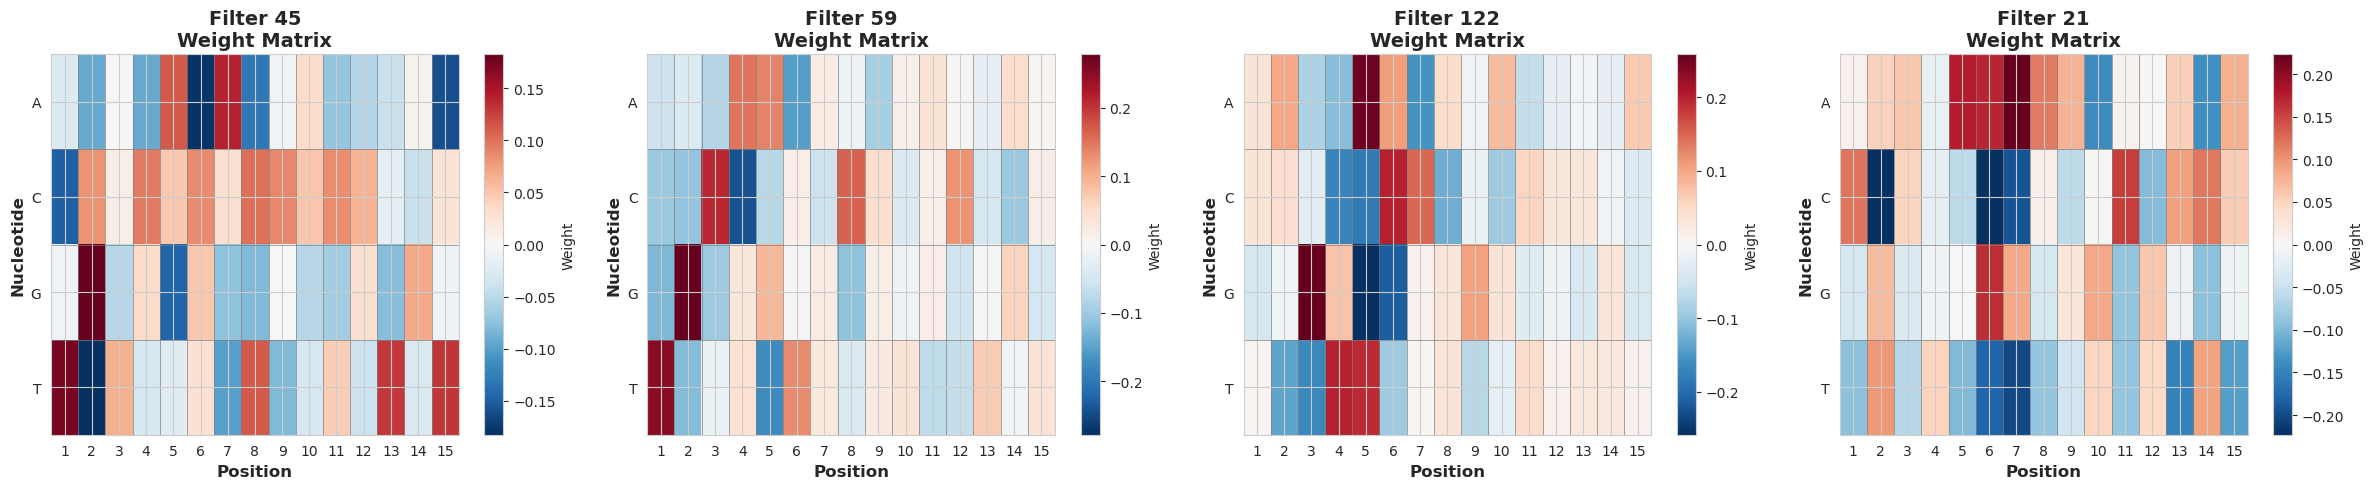


Extracting consensus sequences...

Filter 45:
  Max sequence:       TGTCACATCCCCTGT
  Consensus (>25%):   TSYSMBMYCMYSTRY
  Position-wise probabilities:
    Pos  1: T (29.61%)
    Pos  2: G (29.93%) | C(27.07%)
    Pos  3: T (26.50%) | C(25.09%)
    Pos  4: C (27.36%) | G(25.79%)
    Pos  5: A (27.87%) | C(26.20%)
    Pos  6: C (27.21%) | G(26.24%), T(25.68%)
    Pos  7: A (28.67%) | C(25.64%)
    Pos  8: T (27.79%) | C(27.46%)
    Pos  9: C (27.23%)
    Pos 10: C (26.26%) | A(25.82%)
    Pos 11: C (27.17%) | T(26.11%)
    Pos 12: C (26.61%) | G(25.72%)
    Pos 13: T (28.41%)
    Pos 14: G (26.73%) | A(25.08%)
    Pos 15: T (28.44%) | C(25.59%)

  Creating sequence logo for Filter 45...


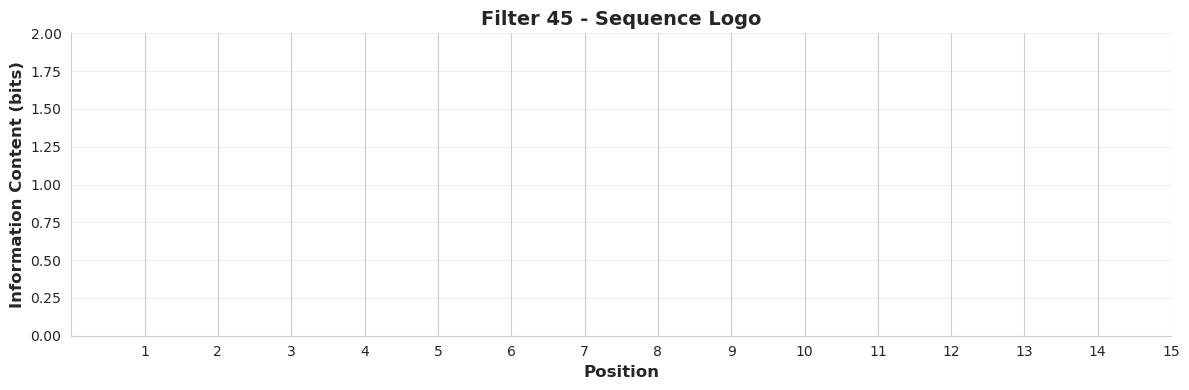


Filter 59:
  Max sequence:       TGCAATTCCTACTGT
  Consensus (>25%):   TGCDRYDCBWVCTRH
  Position-wise probabilities:
    Pos  1: T (32.02%)
    Pos  2: G (32.49%)
    Pos  3: C (30.55%)
    Pos  4: A (28.88%) | G(25.70%), T(25.90%)
    Pos  5: A (28.62%) | G(27.35%)
    Pos  6: T (28.44%) | C(25.40%)
    Pos  7: T (25.61%) | A(25.43%), G(25.49%)
    Pos  8: C (29.32%)
    Pos  9: C (26.16%) | G(25.43%), T(25.63%)
    Pos 10: T (25.95%) | A(25.34%)
    Pos 11: A (25.96%) | C(25.30%), G(25.45%)
    Pos 12: C (28.19%)
    Pos 13: T (26.82%)
    Pos 14: G (26.54%) | A(26.20%)
    Pos 15: T (25.84%) | A(25.09%), C(25.34%)

  Creating sequence logo for Filter 59...


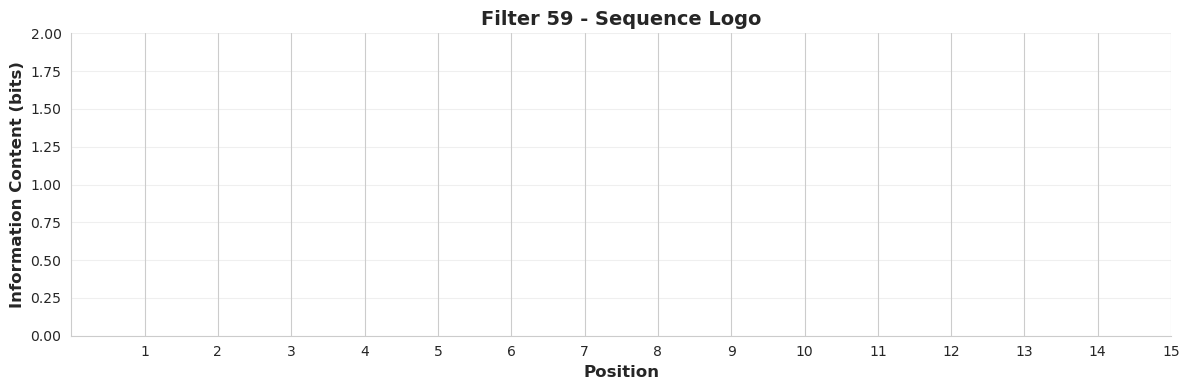


Filter 122:
  Max sequence:       CAGTACCAGACCCGA
  Consensus (>25%):   MMGKWMSDGRYYYKW
  Position-wise probabilities:
    Pos  1: C (25.69%) | A(25.63%)
    Pos  2: A (27.54%) | C(26.05%)
    Pos  3: G (32.09%)
    Pos  4: T (30.25%) | G(26.67%)
    Pos  5: A (31.78%) | T(30.00%)
    Pos  6: C (30.08%) | A(27.50%)
    Pos  7: C (28.74%) | G(25.06%)
    Pos  8: A (26.20%) | G(25.84%), T(25.90%)
    Pos  9: G (27.62%)
    Pos 10: A (27.08%) | G(25.79%)
    Pos 11: C (26.31%) | T(26.12%)
    Pos 12: C (25.72%) | T(25.27%)
    Pos 13: C (25.69%) | T(25.60%)
    Pos 14: G (25.64%) | T(25.48%)
    Pos 15: A (26.70%) | T(25.24%)

  Creating sequence logo for Filter 122...


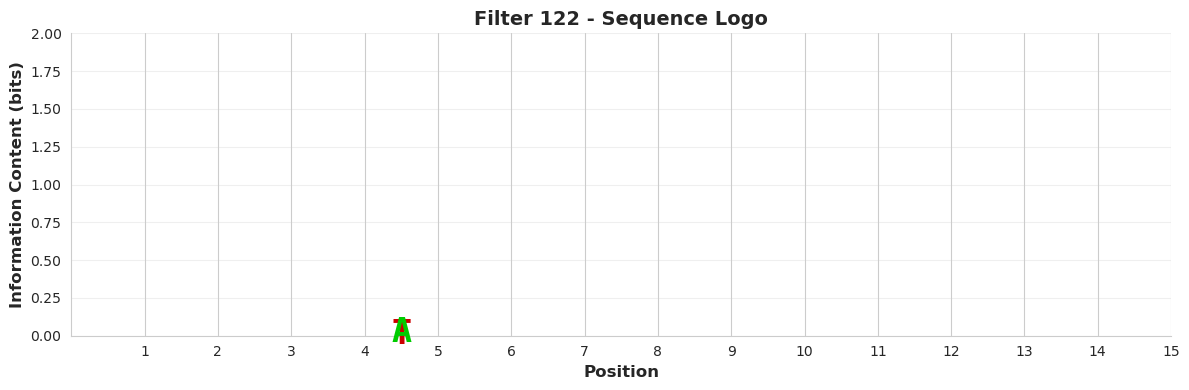


Filter 21:
  Max sequence:       CTATAAAAAGCGCCA
  Consensus (>25%):   MDMTARRMRBMKMYM
  Position-wise probabilities:
    Pos  1: C (28.10%) | A(25.18%)
    Pos  2: T (27.51%) | A(26.30%), G(26.82%)
    Pos  3: A (26.42%) | C(26.14%)
    Pos  4: T (26.25%)
    Pos  5: A (29.48%)
    Pos  6: A (29.65%) | G(29.50%)
    Pos  7: A (31.40%) | G(27.33%)
    Pos  8: A (27.99%) | C(25.17%)
    Pos  9: A (26.96%) | G(25.61%)
    Pos 10: G (27.19%) | C(25.00%), T(26.17%)
    Pos 11: C (29.11%) | A(25.14%)
    Pos 12: G (26.48%) | T(26.04%)
    Pos 13: C (27.42%) | A(26.39%)
    Pos 14: C (28.10%) | T(27.31%)
    Pos 15: A (26.96%) | C(26.39%)

  Creating sequence logo for Filter 21...


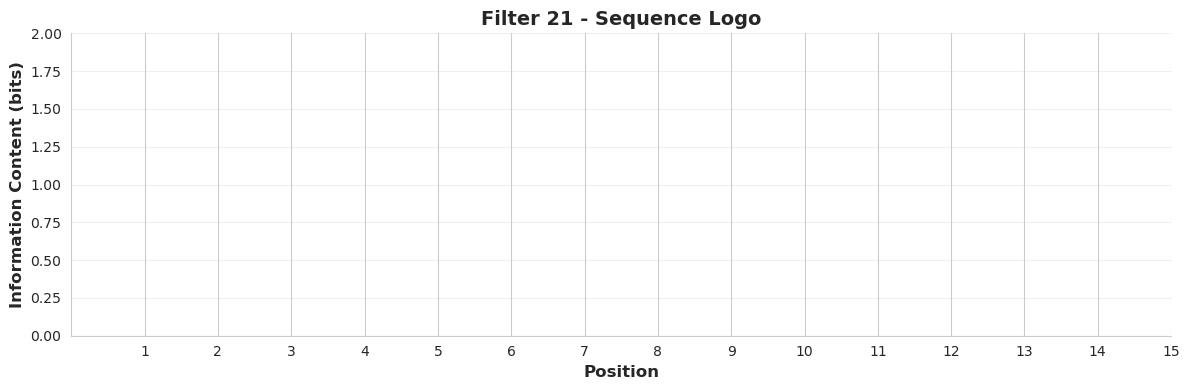


Saved consensus sequences to: sineB2_filters_consensus_sequences.tsv


In [20]:
# Analyze filters
results = analyze_filters(model, FILTER_INDICES, output_prefix='sineB2_filters')

In [21]:
# Compare to known motifs
max_sequences = [r['max_sequence'] for r in results]
compare_to_known_motifs(max_sequences, FILTER_INDICES)


CHECKING FOR KNOWN PATTERNS

Filter 45: TGTCACATCCCCTGT
  GC content: 53.3%
  No known pattern matches

Filter 59: TGCAATTCCTACTGT
  GC content: 40.0%
  No known pattern matches

Filter 122: CAGTACCAGACCCGA
  GC content: 60.0%
  No known pattern matches

Filter 21: CTATAAAAAGCGCCA
  GC content: 40.0%
  No known pattern matches
